# 2. Roughness 

In [ ]:
import numpy as np
import pandas as pd
import os

from surface_functions import compute_surface_roughness

Organization of this notebook:
1) We open sequentially each dataframe (per noise type, per delta).
2) The roughness corresponding to each simulation is computed from the phases. Then they are added as a new column to the corresponding dataframe.
3) Then, the average roughness is computed, grouping by K, L. The result is stored in the summary_rows list.
4) This information is then saved on an AverageSims array, containing all the simulations per noise type, delta, K, L. 

In [27]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"Output{typenoise}/Solutions_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        roughness_list = []  # used to compute per-sim roughness

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            roughness = np.asarray(compute_surface_roughness(phases), dtype=float)

            roughness_list.append(roughness)

        # Avoid chained-assignment issues
        df = df.copy()
        df["roughness"] = roughness_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE ROUGHNESS PER (K, L) ##
        # group by K, L and compute mean roughness for each group
        for (K_val, L_val), group in df.groupby(["K", "L"]):
            rough_arrays = [np.asarray(r, dtype=float) for r in group["roughness"]]
            mean_roughness = np.mean(np.stack(rough_arrays, axis=0), axis=0)

            # assume all t are identical within group; take the first
            t = group.iloc[0]["t"]
            seed_list = group.index.tolist()
            M = len(seed_list) 

            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "typenoise": typenoise,
                    "delta": delta,
                    "deltaname": deltaname,
                    "K": K_val,
                    "L": L_val,
                    "t": t,
                    "M": M,
                    "mean_roughness": mean_roughness,
                }
            )

        print("Seeds (index):", df.index.tolist())
        print("Number of simulations:", M)
        print("Columns:", df.columns.tolist())

## TimeDep – Delta 0
Seeds (index): ['L500_K1_seed78375102', 'L500_K1_seed48022158', 'L500_K1_seed21517135', 'L500_K1_seed73450932', 'L500_K1_seed5701930', 'L500_K0.01_seed66323775', 'L500_K1_seed66955334', 'L500_K0.01_seed51276577', 'L500_K1_seed66776927', 'L500_K0.01_seed39155229', 'L500_K1_seed10688739', 'L500_K0.01_seed74911657', 'L500_K1_seed14995512', 'L500_K0.01_seed92687884', 'L500_K1_seed11013623', 'L500_K0.01_seed77570756', 'L500_K1_seed26524819', 'L500_K0.01_seed87634771', 'L500_K1_seed61884301', 'L500_K0.01_seed87439695', 'L500_K1_seed70493549', 'L500_K0.01_seed46007736', 'L500_K1_seed16437593', 'L500_K0.01_seed55248971', 'L500_K1_seed13595782', 'L500_K0.01_seed18901207', 'L500_K1_seed41894445', 'L500_K0.01_seed90297636', 'L500_K1_seed7367704', 'L500_K0.01_seed24097069', 'L500_K1_seed78608552', 'L500_K0.01_seed73001616', 'L500_K1_seed46449722', 'L500_K0.01_seed31008285', 'L500_K1_seed22480058', 'L500_K1_seed4733608', 'L500_K0.01_seed39831824', 'L500_K1_seed92871047', 'L500_

In [28]:
# Note: we start from scratch the average DataFrame (each time this script is run)
avg_df = pd.DataFrame()
avg_df_path = "AverageSims.pkl"

# Build/update AverageSims dataframe
if summary_rows:
    new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
    if avg_df.empty:
        avg_df = new_avg
    else:
        # ensure we have an index; if not, give it one
        if avg_df.index.name is None:
            avg_df = avg_df.copy()
            avg_df.index.name = "avg_id"
        avg_df = pd.concat([avg_df, new_avg])
        # keep last occurrence per avg_id
        avg_df = avg_df[~avg_df.index.duplicated(keep="last")]

    avg_df.to_pickle(avg_df_path)
    print("Saved AverageSims to:", avg_df_path)

Saved AverageSims to: AverageSims.pkl


In [29]:
avg_df

,typenoise,delta,deltaname,K,L,t,M,mean_roughness
avg_id,,,,,,,,
TimeDep_delta0_L500_K0.01,TimeDep,0.000000,0,0.01,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,"[0.0, 0.09932794776024303, 0.12445710235930987..."
TimeDep_delta0_L500_K1.0,TimeDep,0.000000,0,1.00,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,"[0.0, 0.062281209851627814, 0.0703404523305143..."
TimeDep_deltaatan5_L500_K0.01,TimeDep,1.373401,atan5,0.01,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,"[0.0, 0.10014740577543957, 0.1261770083222738,..."
TimeDep_deltaatan5_L500_K1.0,TimeDep,1.373401,atan5,1.00,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,"[0.0, 0.08538735713321526, 0.10092130285727816..."
Columnar_delta0_L500_K0.02,Columnar,0.000000,0,0.02,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,"[0.0, 0.5718230273546884, 0.9065624021882813, ..."
Columnar_delta0_L500_K2.0,Columnar,0.000000,0,2.00,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",416,"[0.0, 0.27977017401912224, 0.39268233081382764..."
Columnar_deltaatan5_L500_K0.02,Columnar,1.373401,atan5,0.02,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,"[0.0, 0.5811838068310373, 0.9255341841702291, ..."
Columnar_deltaatan5_L500_K2.0,Columnar,1.373401,atan5,2.00,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,"[0.0, 0.4773244373991336, 0.9663765470279072, ..."


## Preliminary inspection of the computed quantities

In [3]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science","no-latex"])

In [30]:
avg_df_path = "AverageSims.pkl"
avg_df = pd.read_pickle(avg_df_path)

### Large coupling = KPZ, EW

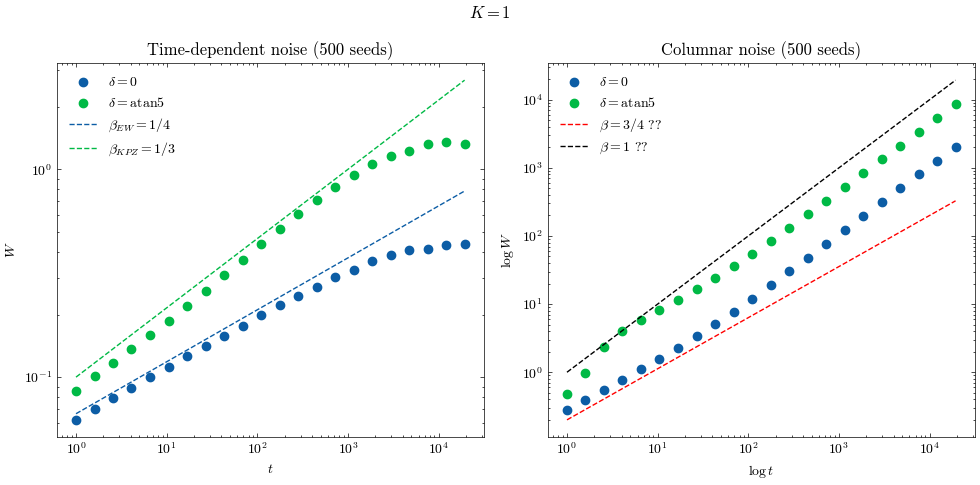

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
fig.suptitle("$K=1$")

ax[0].set_xlabel("$t$")
ax[0].set_ylabel("$W$")
ax[1].set_xlabel(r"$\log t$")
ax[1].set_ylabel(r"$\log W$")

for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent noise", "Columnar noise"])
):

    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        # select rows for this noise type and delta
        mask = mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["deltaname"] == deltaname)
            & ((avg_df["K"] == 1) | (avg_df["K"] == 2))
        )
        sub = avg_df[mask]

        # in case there are multiple (K, L) combos, plot them all
        for _, row in sub.iterrows():
            t = row["t"]
            mean_roughness = row["mean_roughness"]

            ax[i].scatter(t, mean_roughness, label=r"$\delta=$" + deltaname)
            ax[i].set_title(typelabel+ f" ({M} seeds)")

ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xscale('log')

ax[0].loglog(t[1::], t[1::]**(1/4) /15, label=r"$\beta_{EW}=1/4$", linestyle="--")
ax[0].loglog(t[1::], t[1::]**(1/3) /10, label=r"$\beta_{KPZ}=1/3$", linestyle="--")

ax[1].loglog(t[1::], t[1::]**(3/4) /5, label=r"$\beta=3/4$ ??", linestyle="--", color="r")
ax[1].loglog(t[1::], t[1::]**(1) , label=r"$\beta=1$ ??", linestyle="--", color="k")

ax[0].legend()
ax[1].legend()

plt.tight_layout()
plt.show()

- K pequeño (ver exponente de random deposition) CUDIDADO QUE NO ES K/N
- Repetir para ruido columnar. Las pendientes deben ser casi iguales.
- Ampliar el tiempo de cálculo.
- Guardar en espaciado logarítmico los datos directamente.

### Small coupling = Random deposition

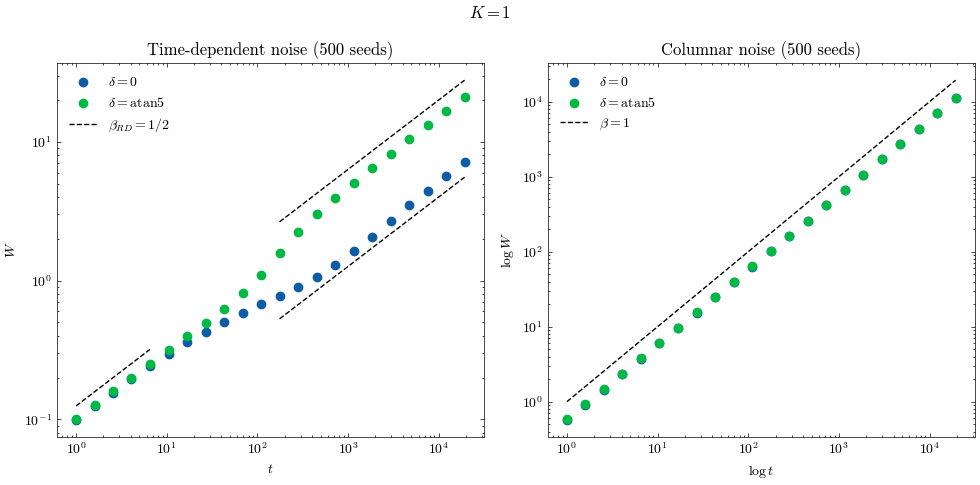

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
fig.suptitle("$K=1$")

ax[0].set_xlabel("$t$")
ax[0].set_ylabel("$W$")
ax[1].set_xlabel(r"$\log t$")
ax[1].set_ylabel(r"$\log W$")

for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent noise", "Columnar noise"])
):

    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        # select rows for this noise type and delta
        mask = mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["deltaname"] == deltaname)
            & ((avg_df["K"] == 0.01) | (avg_df["K"] == 0.02))
        )
        sub = avg_df[mask]

        # in case there are multiple (K, L) combos, plot them all
        for _, row in sub.iterrows():
            t = row["t"]
            mean_roughness = row["mean_roughness"]

            ax[i].scatter(t, mean_roughness, label=r"$\delta=$" + deltaname)
            ax[i].set_title(typelabel+ f" ({M} seeds)")

ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xscale('log')

ax[0].loglog(t[12::], t[12::]**(1/2) /5, label=r"$\beta_{RD}=1/2$", linestyle="--", color="k")
ax[0].loglog(t[12::], t[12::]**(1/2) /25, linestyle="--", color="k")
ax[0].loglog(t[1:6:], t[1:6:]**(1/2) /8, linestyle="--", color="k")

ax[1].loglog(t[1::], t[1::]**(1), label=r"$\beta=1$", linestyle="--", color="k")

ax[0].legend()
ax[1].legend()

plt.tight_layout()
plt.show()